In [1]:
# Cell 1: imports & renderer
import io, math, time, os, numpy as np, matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from IPython.display import display, Image as IPyImage

In [ ]:
%cd /Users/adamsobieszek/PycharmProjects/ManipyTraversal
from lib import *
from models.gan_load import build_biggan, build_proggan, build_stylegan2,build_stylegan2mps, build_sngan
# --- Minimal params to satisfy Trainer + pretrain call ---
class Params:
    # bookkeeping (unused in pretrain)
    tensorboard = False
    ce_label_smoothing = 0.0
    conf_penalty_weight = 0.0

    # core config
    cuda = False
    mps = True
    new_experiment = True

    # pretrain knobs
    # pretrain_batch_size = 256
    # pretrain_lr = 1e-4
    # pretrain_time_random = True
    # pretrain_consistency_sigma = 0.05
    # pretrain_target_grad_norm = .0
    # pretrain_lambda_orth = 1.0
    # pretrain_lambda_in = 2.0
    # pretrain_lambda_consistency = 0.2
    # pretrain_lambda_norm = 0.0
    pretrain_log_freq = 20
    pretrain_amp = False  # turn True if you want

    # W stats
    z_truncation = 0.7
    pretrain_w_stats_samples = 20000
    pretrain_w_stats_batch = 1024
    gan_type="SNGAN_AnimeFaces"
    stylegan2_resolution=256
    shift_in_w_space=True
    num_support_sets=8
    num_support_timesteps=10
    warmup_fraction=0.05
    accumulate_grad_steps=10
    reconstructor_type="LeNet"
    batch_size=32
    max_iter=120000



# Parse given arguments
args = Params()
params = args


# Create output dir and save current arguments
exp_dir = create_exp_dir(args, new_experiment=args.new_experiment)

# Device selection (CUDA > MPS > CPU)
cuda_available = torch.cuda.is_available()
mps_available = hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()

if args.cuda and not cuda_available:
    print("*** WARNING ***: CUDA was requested but is not available. Falling back to CPU/MPS.\n"
            "                 On Apple Silicon, try --mps if supported by your PyTorch build.")
if args.mps and not mps_available:
    print("*** WARNING ***: MPS was requested but is not available. Falling back to CPU/CUDA.")
if cuda_available and not args.cuda:
    print("*** WARNING ***: It looks like you have a CUDA device, but aren't using CUDA.\n"
            "                 Run with --cuda for optimal training speed.")

use_cuda = args.cuda and cuda_available
use_mps = args.mps and mps_available
device = torch.device('cuda' if use_cuda else ('mps' if use_mps else 'cpu'))

# Set default tensor type for CUDA only (no MPS default tensor type exists)
if use_cuda:
    torch.set_default_tensor_type('torch.cuda.FloatTensor')
else:
    torch.set_default_tensor_type('torch.FloatTensor')

multi_gpu = use_cuda and (torch.cuda.device_count() > 1)

# Build GAN generator model and load with pre-trained weights
print("#. Build GAN generator model G and load with pre-trained weights...")
print("  \\__GAN type: {}".format(args.gan_type))
if args.gan_type == 'StyleGAN2':
    print("  \\__Search for paths in {}-space".format('W' if args.shift_in_w_space else 'Z'))
if args.z_truncation:
    print("  \\__Input noise truncation: {}".format(args.z_truncation))
print("  \\__Pre-trained weights: {}".format(
    GAN_WEIGHTS[args.gan_type]['weights'][args.stylegan2_resolution] if args.gan_type == 'StyleGAN2' else
    GAN_WEIGHTS[args.gan_type]['weights'][GAN_RESOLUTIONS[args.gan_type]]))

# === BigGAN ===
if args.gan_type == 'BigGAN':
    G = build_biggan(pretrained_gan_weights=GAN_WEIGHTS[args.gan_type]['weights'][GAN_RESOLUTIONS[args.gan_type]],
                        target_classes=args.biggan_target_classes)
    print(G.device,G)
    print(G(torch.randn(1, 512).to(G.device)))
# === ProgGAN ===
elif args.gan_type == 'ProgGAN':
    G = build_proggan(pretrained_gan_weights=GAN_WEIGHTS[args.gan_type]['weights'][GAN_RESOLUTIONS[args.gan_type]])
# === StyleGAN ===
elif args.gan_type == 'StyleGAN2':
    if use_mps:
        G = build_stylegan2mps(pretrained_gan_weights=GAN_WEIGHTS[args.gan_type]['weights'][args.stylegan2_resolution],
                        resolution=args.stylegan2_resolution,
                        shift_in_w_space=args.shift_in_w_space)
    else:   
        G = build_stylegan2(pretrained_gan_weights=GAN_WEIGHTS[args.gan_type]['weights'][args.stylegan2_resolution],
                        resolution=args.stylegan2_resolution,
                        shift_in_w_space=args.shift_in_w_space)
# === Spectrally Normalised GAN (SNGAN) ===
else:
    G = build_sngan(pretrained_gan_weights=GAN_WEIGHTS[args.gan_type]['weights'][GAN_RESOLUTIONS[args.gan_type]],
                    gan_type=args.gan_type)

print("Moving Generator to device {}".format(device))
G.to(device)

# Build Support Sets model S
print("#. Build Support Sets S...")
print("  \\__Number of Potentials    : {}".format(args.num_support_sets))
print("  \\__Number of Timesteps : {}".format(args.num_support_timesteps))
print("  \\__Support Vectors dim       : {}".format(G.dim_z))

S = WavePDE(num_support_sets=args.num_support_sets,
                num_support_timesteps=args.num_support_timesteps,
                support_vectors_dim=G.dim_z)

# For stylegan remove the last activation layer otherwise the changes are too small
if args.gan_type == 'StyleGAN2':
    for i in range(S.num_support_sets):
        S.PSI_SET[i].activation4 = nn.Identity()

# Count number of trainable parameters
print("  \\__Trainable parameters: {:,}".format(sum(p.numel() for p in S.parameters() if p.requires_grad)))

# Build reconstructor model R
print("#. Build reconstructor model R...")

R = Reconstructor(reconstructor_type=args.reconstructor_type,
                    dim_index=S.num_support_sets,
                    dim_time=S.num_support_timesteps,
                    channels=1 if args.gan_type == 'SNGAN_MNIST' else 3)

# Count number of trainable parameters
print("  \\__Trainable parameters: {:,}".format(sum(p.numel() for p in R.parameters() if p.requires_grad)))

# Set up trainer
print("#. Experiment: {}".format(exp_dir))
trn = Trainer(params=args, exp_dir=exp_dir, device=device, use_cuda=use_cuda, use_mps=use_mps, multi_gpu=multi_gpu)


/Users/adamsobieszek/PycharmProjects/ManipyTraversal
Creating new experiment
------------------------------


#. Build GAN generator model G and load with pre-trained weights...
  \__GAN type: SNGAN_AnimeFaces
  \__Input noise truncation: 0.7
  \__Pre-trained weights: models/pretrained/generators/SNGAN_AnimeFaces/generator.pt
Moving Generator to device mps
#. Build Support Sets S...
  \__Number of Potentials    : 8
  \__Number of Timesteps : 10
  \__Support Vectors dim       : 128
  \__Trainable parameters: 529,424
#. Build reconstructor model R...
  \__Trainable parameters: 73,920
#. Experiment: SNGAN_AnimeFaces-LeNet-K8-D10__20250906_084224


/opt/anaconda3/envs/manip311/lib/python3.11/site-packages/torch/__init__.py:1276: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


In [3]:

# Helper to get flattened W dimension
@torch.no_grad()
def get_w_dim(gen, dim_z, truncation, device):
    z = torch.randn(4, dim_z, device=device)
    w = gen.get_w(z)
    if w.dim() > 2:
        w = w.reshape(w.size(0), -1)
    return w.size(1)

D = G.dim_z#get_w_dim(G, G.dim_z, params.z_truncation, device)
print(f"W (flattened) dim = {D}")




W (flattened) dim = 128


In [4]:
# Cell 3: run pretraining (no images, only W-map used)
trainer = trn
generator = G
support_sets = S
trainer.contrastive_pretrain_potentials(generator, support_sets)


   - Using Z prior N(0,I); no W stats needed.


/Users/adamsobieszek/PycharmProjects/ManipyTraversal/lib/trainer.py:439: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/Users/adamsobieszek/PycharmProjects/ManipyTraversal/lib/trainer.py:576: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"loss={float(loss):.5f} | "


[pretrain 000020/000200] loss=10530.69629 | orth=0.00854 in=1762.15466 cons=0.00220 norm=0.00000 pde=8768.53125 cons=0.00220 (dt=10.0s)
[pretrain 000040/000200] loss=3329.83496 | orth=0.00510 in=670.19067 cons=0.01409 norm=0.00000 pde=2659.62500 cons=0.01409 (dt=9.0s)
[pretrain 000060/000200] loss=1530.04199 | orth=0.00931 in=361.31396 cons=0.01481 norm=0.00000 pde=1168.70386 cons=0.01481 (dt=9.1s)
[pretrain 000080/000200] loss=1184.37061 | orth=0.00996 in=289.81573 cons=0.01232 norm=0.00000 pde=894.53265 cons=0.01232 (dt=8.9s)
[pretrain 000100/000200] loss=958.89642 | orth=0.01180 in=262.03687 cons=0.01192 norm=0.00000 pde=696.83582 cons=0.01192 (dt=9.0s)
[pretrain 000120/000200] loss=876.21039 | orth=0.01243 in=241.34868 cons=0.01441 norm=0.00000 pde=634.83490 cons=0.01441 (dt=9.1s)
[pretrain 000140/000200] loss=716.92773 | orth=0.01207 in=220.29234 cons=0.01300 norm=0.00000 pde=496.61035 cons=0.01300 (dt=9.2s)
[pretrain 000160/000200] loss=631.83325 | orth=0.01259 in=202.51811 cons=

In [5]:
# Cell 4: PCA-2 on W, density fit in 2D
@torch.no_grad()
def sample_w(generator, n=20000, bs=1024, device=device, z_trunc=1.0):
    outs = []
    left = n
    while left > 0:
        b = min(bs, left)
        z = torch.randn(b, generator.dim_z, device=device)
        if hasattr(generator, 'get_w'):
            w = generator.get_w(z)
        else:
            w = z
        w = w.reshape(b, -1)
        outs.append(w)
        left -= b
    W = torch.cat(outs, dim=0)  # [n, D]
    return W

def pca2(X: torch.Tensor):
    """
    X: [N, D] on device
    returns:
      mu: [D]
      B:  [D, 2]  (columns = top-2 principal directions)
      S:  [2]     singular values
    """
    mu = X.mean(dim=0)
    Xc = X - mu
    # economy SVD via covariance in feature space
    # safer: run SVD on Cpu for large N if you prefer
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
    B = Vh[:2].T  # [D,2]
    return mu, B, S[:2]

def gaussian_pdf_2d(xy: torch.Tensor, mu2: torch.Tensor, cov2: torch.Tensor):
    """
    xy:  [N,2]
    mu2: [2]
    cov2: [2,2] (SPD)
    returns: [N,] pdf values
    """
    diff = xy - mu2[None, :]
    inv = torch.inverse(cov2)
    expo = torch.einsum('ni,ij,nj->n', diff, inv, diff)
    norm = 1.0 / (2.0 * math.pi * torch.sqrt(torch.det(cov2)) + 1e-12)
    return norm * torch.exp(-0.5 * expo)

# --- gather samples & fit PCA ---
W = sample_w(generator, n=20000, bs=1024, device=device)
mu_W, B2, S2 = pca2(W)              # mu_W: [D], B2: [D,2]
# project samples to 2D to fit density (cov2)
W2 = (W - mu_W) @ B2                # [N,2]
mu2 = W2.mean(dim=0)
cov2 = torch.from_numpy(np.cov(W2.detach().cpu().numpy().T)).to(device, dtype=W2.dtype)
print("Fitted PCA-2 & 2D Gaussian on W-projection.")


Fitted PCA-2 & 2D Gaussian on W-projection.


/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_13496/1852479728.py:31: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)


In [ ]:
# Cell 5: build wrappers (vector field, impression, density) per potential
def make_vector_field_and_impressions(support_sets, k: int, t_val: float, mode='raw', device=device):
    """
    Returns two callables consumed by render_streamlines_image:
      - vector_field_fn:  xy -> [N,2] field (projected gradient in the PCA-2 plane)
      - impression_fn:    xy -> [N,]   scalar "background" (here: potential u)
    mode:
      'raw'         : use raw gradient projection
      'tangent'     : remove component along ∇E (2D), to show in-distribution tangents
    """
    mlp = support_sets.PSI_SET[k].to(device).eval()
    c_muW = mu_W.detach()
    c_B2  = B2.detach()

    # energy grad in full W for 'tangent' mode
    # use diag Gaussian stored during pretrain if available; otherwise fallback to PCA-elliptic in 2D
    w_mu = getattr(support_sets, "w_mu", None)
    w_inv_var = getattr(support_sets, "w_inv_var", None)

    @torch.no_grad()
    def _latent_energy_grad_fullW(Wflat):
        if (w_mu is not None) and (w_inv_var is not None):
            return (Wflat - w_mu[None, :]) * w_inv_var[None, :]
        else:
            # fallback: project to 2D, use cov2, then lift back
            W2_ = (Wflat - c_muW) @ c_B2
            # grad E in 2D ~ cov2^{-1} (x - mu2)
            inv2 = torch.inverse(cov2)
            g2 = (W2_ - mu2[None, :]) @ inv2   # [N,2]
            # lift to D via B2
            return g2 @ c_B2.T                  # [N, D]

    @torch.enable_grad()
    def vector_field_fn(xy: torch.Tensor) -> torch.Tensor:
        """
        xy: [N,2] chart coords
        returns: [N,2] projected gradient field
        """
        N = xy.size(0)
        # lift chart -> full W
        Wfull = c_muW[None, :] + xy @ c_B2.T  # [N,D]
        Wfull_req = Wfull.detach().requires_grad_(True)
        t = torch.full((N, 1), float(t_val), device=Wfull.device, dtype=Wfull.dtype)
        u = mlp(Wfull_req, t)                 # [N,1]
        g = torch.autograd.grad(u.sum(), Wfull_req, create_graph=False)[0]  # [N,D]
        if mode == 'tangent':
            gE = _latent_energy_grad_fullW(Wfull)             # [N,D]
            gE_unit = gE / (gE.norm(dim=1, keepdim=True) + 1e-8)
            g = g - (g * gE_unit).sum(dim=1, keepdim=True) * gE_unit
        # project to 2D
        v2 = g @ c_B2      # [N,2]
        # normalize to avoid huge arrows (optional)
        vnorm = v2.norm(dim=1, keepdim=True).clamp_min(1e-8)
        v2n = v2 / vnorm
        return v2n

    def impression_fn(xy: torch.Tensor) -> torch.Tensor:
        N = xy.size(0)
        Wfull = c_muW[None, :] + xy @ c_B2.T
        t = torch.full((N, 1), float(t_val), device=Wfull.device, dtype=Wfull.dtype)
        with torch.no_grad():
            u = mlp(Wfull, t)[:, 0]  # [N]
        # normalize to [0,1] for color range
        u = u - u.min()
        u = u / (u.max() + 1e-12)
        return u

    return vector_field_fn, impression_fn

def density_fn_xy(xy: torch.Tensor, **kwargs):
    # 2D Gaussian pdf on PCA plane
    return gaussian_pdf_2d(xy, mu2, cov2).to(xy.dtype).to(xy.device)


In [7]:

# Helpers to compute gradient field on a grid
@torch.no_grad()
def get_data_bounds(X):
    xmin, ymin = X.min(axis=0)
    xmax, ymax = X.max(axis=0)
    pad_x = 0.1 * (xmax - xmin)
    pad_y = 0.1 * (ymax - ymin)
    return (xmin - pad_x, xmax), (ymin - pad_y, ymax)

# (your provided renderer, with imports wired)
def render_streamlines_image(
    vector_field_fn, impression_fn,
    show_support=True,
    xlim=None, ylim=None,
    density_fn=None, density_kwargs=None, cutoff_p=0.02,
    resolution=100, dpi=100, plot=False, device=None
):
    # 2D *2 /2 search to find support bounds if xlim/ylim are not provided
    if (xlim is None or ylim is None) and density_fn is not None:
        # Initial grid parameters
        grid_res = 100
        initial_span = 10.0  # initial guess for span
        center = np.zeros(2)
        found = False
        max_iter = 12
        span = initial_span
        for _ in range(max_iter):
            # Build grid
            x = np.linspace(center[0] - span, center[0] + span, grid_res)
            y = np.linspace(center[1] - span, center[1] + span, grid_res)
            X, Y = np.meshgrid(x, y)
            grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)
            with torch.no_grad():
                P = density_fn(grid_points).detach().cpu().numpy().reshape(X.shape)
            P_sum = P.sum()
            if P_sum < 1e-8:
                # Distribution is too small, increase span
                span *= 2
                continue
            # Weighted average for center
            weights = P / P_sum
            cx = (X * weights).sum()
            cy = (Y * weights).sum()
            center = np.array([cx, cy])
            # Find where density drops below threshold
            thr = 0.01 * P.max()
            mask = P > thr
            if not np.any(mask):
                span *= 2
                continue
            x_mask = X[mask]
            y_mask = Y[mask]
            xlo, xhi = x_mask.min(), x_mask.max()
            ylo, yhi = y_mask.min(), y_mask.max()
            # Check if support is near grid edge; if so, increase span
            margin = 0.05 * span
            if (abs(xlo - (center[0] - span)) < margin or
                abs(xhi - (center[0] + span)) < margin or
                abs(ylo - (center[1] - span)) < margin or
                abs(yhi - (center[1] + span)) < margin):
                span *= 2
                continue
            # Otherwise, found good bounds
            found = True
            break
        if not found:
            # fallback to default
            xlo, xhi = center[0] - span, center[0] + span
            ylo, yhi = center[1] - span, center[1] + span
        if xlim is None:
            xlim = (float(xlo), float(xhi))
        if ylim is None:
            ylim = (float(ylo), float(yhi))


    fig, ax = plt.subplots(1, 1, figsize=((xlim[1]-xlim[0]), (ylim[1]-ylim[0])), dpi=dpi)
    # Build grid
    x_range = np.linspace(xlim[0], xlim[1], resolution)
    y_range = np.linspace(ylim[0], ylim[1], resolution)
    X, Y = np.meshgrid(x_range, y_range)
    grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)

    # Evaluate fields
    with torch.no_grad():
        Z = impression_fn(grid_points).detach().cpu().numpy().reshape(X.shape)
        V = vector_field_fn(grid_points).detach().cpu().numpy()
    Ux = V[:, 0].reshape(X.shape)
    Uy = V[:, 1].reshape(X.shape)

    # --- draw with Matplotlib (OFF-SCREEN) ---
    # cf = ax.contourf(X, Y, Z, levels=24, cmap='viridis', alpha=0.75)
    ax.streamplot(X, Y, Ux, Uy, color='w', density=1., linewidth=1.1, arrowsize=1.6, broken_streamlines=False)

    if show_support and density_fn is not None:
        with torch.no_grad():
            P = density_fn(grid_points, **(density_kwargs or {})).detach().cpu().numpy().reshape(X.shape)
        thr = cutoff_p * np.max(P)
        ax.contour(X, Y, P, levels=[thr], colors='k', linewidths=2.0, linestyles='-.')
        cf = ax.contourf(X, Y, P, levels=24, cmap='viridis', alpha=0.75)

    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.set_title('Potential Flow vs. Latent Density')
    ax.grid(True, alpha=0.3)

    if not plot:
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight', dpi=dpi)
        plt.close(fig)
        buf.seek(0)
        from PIL import Image as PILImage
        im = np.array(PILImage.open(buf).convert('RGBA'))
        buf.close()
        return im
    else:
        plt.show()


Potential k=0, t=0.0, mode=raw


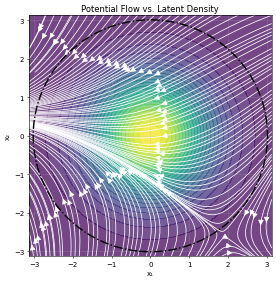

Potential k=0, t=3.0, mode=raw


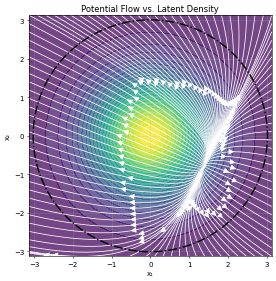

Potential k=0, t=6.0, mode=raw


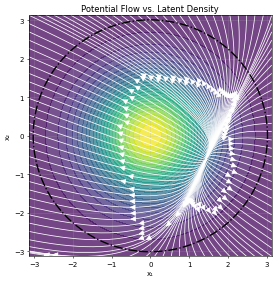

Potential k=1, t=0.0, mode=raw


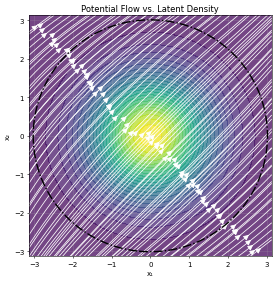

Potential k=1, t=3.0, mode=raw


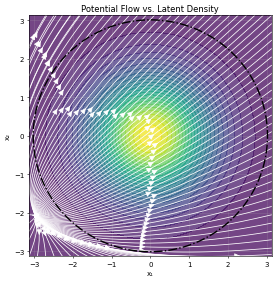

Potential k=1, t=6.0, mode=raw


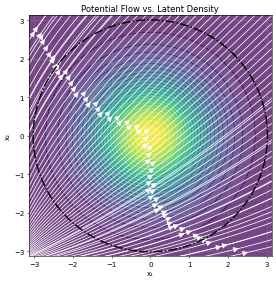

Potential k=2, t=0.0, mode=raw


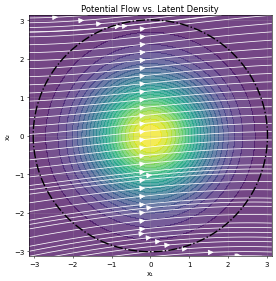

Potential k=2, t=3.0, mode=raw


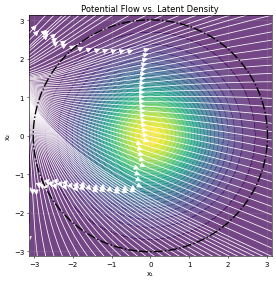

Potential k=2, t=6.0, mode=raw


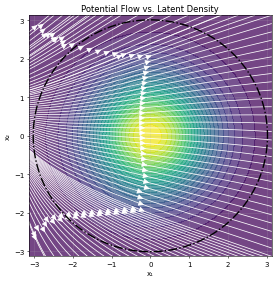

Potential k=3, t=0.0, mode=raw


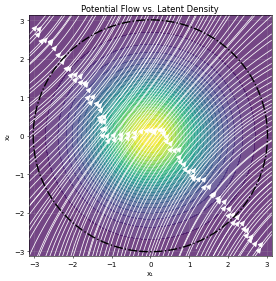

Potential k=3, t=3.0, mode=raw


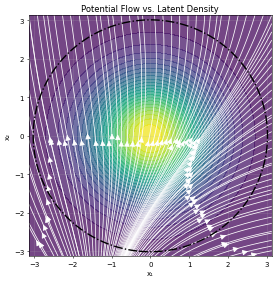

Potential k=3, t=6.0, mode=raw


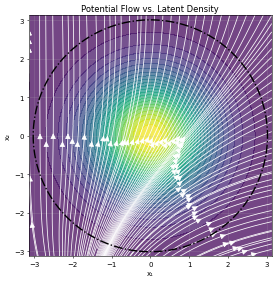

In [8]:
# Cell 6: viz a handful of potentials
device = next(support_sets.parameters()).device

# choose which potentials and times
potentials_to_show = [0, 1, 2, 3]              # pick any K indices
times_to_show      = [0.0, 3.0, 6.0]           # any t within your T
mode               = 'raw'                     # or 'tangent'

imgs = []
for k in potentials_to_show:
    for tval in times_to_show:
        vec_fn, impr_fn = make_vector_field_and_impressions(support_sets, k=k, t_val=tval, mode=mode, device=device)
        print(f"Potential k={k}, t={tval:.1f}, mode={mode}")

        im = render_streamlines_image(
            vector_field_fn=vec_fn,
            impression_fn=impr_fn,
            show_support=True,
            density_fn=density_fn_xy,
            density_kwargs=None,
            cutoff_p=0.02,
            resolution=140, dpi=50,
            plot=True, device=device
        )

In [ ]:
import math, numpy as np, torch
import matplotlib.pyplot as plt

# ---------- Gaussian helpers (Z: N(0,I), W: diag-Gaussian) ----------
def _estimate_w_diag_stats(get_w_fn, dim_z, n_samples=50000, batch_size=1024, device='cuda', truncation_psi=1.0):
    mu = None
    m2 = None
    seen = 0
    while seen < n_samples:
        this_bs = min(batch_size, n_samples - seen)
        z = torch.randn(this_bs, dim_z, device=device)
        with torch.no_grad():
            w = get_w_fn(z, truncation_psi=truncation_psi)  # [B, D_w]
        if mu is None:
            D = w.shape[1]
            mu = torch.zeros(D, device=device, dtype=w.dtype)
            m2 = torch.zeros(D, device=device, dtype=w.dtype)
        seen += this_bs
        # Welford
        delta = w.mean(dim=0) - mu
        mu = mu + delta * (this_bs / seen)
        m2 = m2 + ((w - mu).pow(2).sum(dim=0))
    var = (m2 / max(1, (seen - 1))).clamp_min(1e-8)
    inv_var = 1.0 / var
    return mu, inv_var

def _log_prob_Z(z):
    # z ~ N(0,I)
    D = z.shape[1]
    const = -0.5 * D * math.log(2*math.pi)
    quad = -0.5 * (z.pow(2).sum(dim=1))
    return const + quad  # [B]

def _log_prob_Wdiag(w, mu, inv_var):
    # w ~ N(mu, diag(var)) with inv_var = 1/var
    D = w.shape[1]
    quad = -0.5 * ((w - mu) ** 2 * inv_var).sum(dim=1)  # [B]
    # constant term: -0.5 * ( D*log(2π) + sum(log σ^2) ), but log σ^2 = -log inv_var
    const = -0.5 * (D * math.log(2*math.pi) - torch.log(inv_var).sum())
    return quad + const  # [B]

# ---------- Main visualization ----------
@torch.no_grad()
def summarize_potential_trajectories(
    support_sets,           # WavePDE
    generator,              # generator with .get_w if shift_in_w_space=True
    num_samples=4096,       # total starting latents to average over
    batch_size=256,         # minibatch for the rollout
    potentials=None,        # list of k indices; if None -> all K
    half_range=None,        # if None -> support_sets.num_support_timesteps // 2
    use_w=None,             # if None -> generator.shift_in_w_space if present else False
    mu=None, inv_var=None,  # W stats; if None and use_w=True -> estimate quickly
    estimate_w_stats_samples=20000,  # speedier default for viz
    estimate_w_stats_batch=512,
    truncation_psi=1.0,     # forwarded to get_w
    device=None,            # torch.device
    figsize_per_plot=(5.0, 2.8),
    show_density_line=True,
):
    """
    Builds two figures:
      fig1: 'shape' — mean potential value per time step (backward + forward) for each potential (subplot per k).
      fig2: density — mean log-density and mean density per time step (backward + forward) (subplot per k).
    """
    device = device or next(support_sets.parameters()).device
    K = support_sets.num_support_sets
    if potentials is None:
        potentials = list(range(K))
    if half_range is None:
        half_range = max(1, support_sets.num_support_timesteps // 2)

    # Are we in W-space?
    if use_w is None:
        use_w = bool(getattr(generator, "shift_in_w_space", False))

    # Prepare W stats if needed
    if use_w:
        if mu is None or inv_var is None:
            print(f"[summarize] estimating W diag-Gaussian stats (n={estimate_w_stats_samples})...")
            mu, inv_var = _estimate_w_diag_stats(
                generator.get_w, generator.dim_z,
                n_samples=estimate_w_stats_samples,
                batch_size=estimate_w_stats_batch,
                device=device,
                truncation_psi=truncation_psi
            )
        mu = mu.to(device)
        inv_var = inv_var.to(device)

    # Utility: sample base latents in chosen space
    def sample_latents(bs):
        z = torch.randn(bs, generator.dim_z, device=device)
        if use_w:
            return generator.get_w(z, truncation_psi=truncation_psi)  # [B, D_w]
        else:
            return z  # [B, D_z]

    # Utility: log p(lat)
    def mean_logp(lat):
        if use_w:
            return _log_prob_Wdiag(lat, mu, inv_var).mean().item()
        else:
            return _log_prob_Z(lat).mean().item()

    def mean_p(lat):
        # note: in high dimensions mean density can underflow to 0 — that’s OK; we still plot it
        if use_w:
            lp = _log_prob_Wdiag(lat, mu, inv_var)
        else:
            lp = _log_prob_Z(lat)
        return lp.exp().mean().item()

    # ---------- Accumulators over all starting samples ----------
    # For each k: store concatenated arrays (length = 2*half_range + 1)
    results_shape = {k: np.zeros(2*half_range + 1, dtype=np.float64) for k in potentials}
    results_logp  = {k: np.zeros(2*half_range + 1, dtype=np.float64) for k in potentials}
    results_p     = {k: np.zeros(2*half_range + 1, dtype=np.float64) for k in potentials}

    # We'll aggregate means by summing batch means weighted by batch size, then / total_count at the end
    counts = 0

    # Roll through starting batches
    support_sets.eval()
    total_batches = math.ceil(num_samples / batch_size)
    for b in range(total_batches):
        this_bs = min(batch_size, num_samples - counts)
        counts += this_bs

        z0 = sample_latents(this_bs)  # [B, D]
        # For each potential, we need **independent** center copies (we don’t want updates from k1 affecting k2)
        for k in potentials:
            mlp_k = support_sets.PSI_SET[k]
            # ---- forward rollout ----
            z_f = z0.clone()
            u_means_fwd = []
            logp_means_fwd = []
            p_means_fwd = []
            for s in range(0, half_range + 1):
                t = torch.full((this_bs, 1), float(s), device=device)
                u, u_z = support_sets.inference(k, z_f, t, generator=None, direction=+1)  # u:[B,1], u_z:[B,D]
                # record stats BEFORE stepping
                u_means_fwd.append(u.mean().item())
                logp_means_fwd.append(mean_logp(z_f))
                p_means_fwd.append(mean_p(z_f))
                # step forward
                z_f = (z_f + u_z).detach()

            # ---- backward rollout ----
            z_b = z0.clone()
            u_means_bwd = []
            logp_means_bwd = []
            p_means_bwd = []
            for s in range(0,-half_range-1,-1):
                t = torch.full((this_bs, 1), float(s), device=device)
                u, u_z = support_sets.inference(k, z_b, t, generator=None, direction=-1)
                u_means_bwd.append(u.mean().item())
                logp_means_bwd.append(mean_logp(z_b))
                p_means_bwd.append(mean_p(z_b))
                # step backward (negative direction)
                z_b = (z_b + u_z).detach()

            # Concatenate: [-half..-1] + [0] + [1..+half]
            # Note: u/logp/p at s=0 is present in both lists; include it only once.
            path_u  = list(reversed(u_means_bwd)) + u_means_fwd[1:]
            path_lp = list(reversed(logp_means_bwd)) + logp_means_fwd[1:]
            path_p  = list(reversed(p_means_bwd)) + p_means_fwd[1:]

            # Weighted accumulate
            results_shape[k] += np.array(path_u, dtype=np.float64) * this_bs
            results_logp[k]  += np.array(path_lp, dtype=np.float64) * this_bs
            results_p[k]     += np.array(path_p, dtype=np.float64) * this_bs

    # Normalize to true means over all starting points
    for k in potentials:
        results_shape[k] /= counts
        results_logp[k]  /= counts
        results_p[k]     /= counts

    # ---------- Plotting ----------
    n = len(potentials)
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    # 1) Shape (mean potential per step)
    fig1, axes1 = plt.subplots(rows, cols, figsize=(cols*figsize_per_plot[0], rows*figsize_per_plot[1]), squeeze=False)
    # 2) Density (mean log p and mean p per step)
    fig2, axes2 = plt.subplots(rows, cols, figsize=(cols*figsize_per_plot[0], rows*figsize_per_plot[1]), squeeze=False)

    xs = np.arange(-half_range, half_range + 1)
    for idx, k in enumerate(potentials):
        r = idx // cols
        c = idx % cols

        # --- fig1: potential shape ---
        ax1 = axes1[r, c]
        ax1.plot(xs, results_shape[k], label=f"u mean (k={k})", lw=2.0)
        ax1.axvline(0, color='k', alpha=0.3, lw=1)
        ax1.grid(alpha=0.25)
        ax1.set_title(f"Potential {k} — shape")
        ax1.set_xlabel("discrete step (− backward … + forward)")
        ax1.set_ylabel("E[u_t]")
        ax1.legend(loc='best', fontsize=8)

        # --- fig2: density over trajectory ---
        ax2 = axes2[r, c]
        ax2.plot(xs, results_logp[k], color='C1', lw=2.0, label="mean log p")
        if show_density_line:
            ax2_t = ax2.twinx()
            ax2_t.plot(xs, results_p[k], color='C2', lw=1.5, ls='--', label="mean p")
            ax2_t.set_ylabel("mean density")
            # combine legends
            lines, labels = ax2.get_legend_handles_labels()
            lines2, labels2 = ax2_t.get_legend_handles_labels()
            ax2.legend(lines + lines2, labels + labels2, loc='best', fontsize=8)
        else:
            ax2.legend(loc='best', fontsize=8)
        ax2.axvline(0, color='k', alpha=0.3, lw=1)
        ax2.grid(alpha=0.25)
        ax2.set_title(f"Potential {k} — density")
        ax2.set_xlabel("discrete step (− backward … + forward)")
        ax2.set_ylabel("mean log p")

    # Hide any empty subplots
    for idx in range(n, rows*cols):
        r = idx // cols
        c = idx % cols
        fig1.delaxes(axes1[r, c])
        fig2.delaxes(axes2[r, c])

    fig1.tight_layout()
    fig2.tight_layout()
    return fig1, fig2

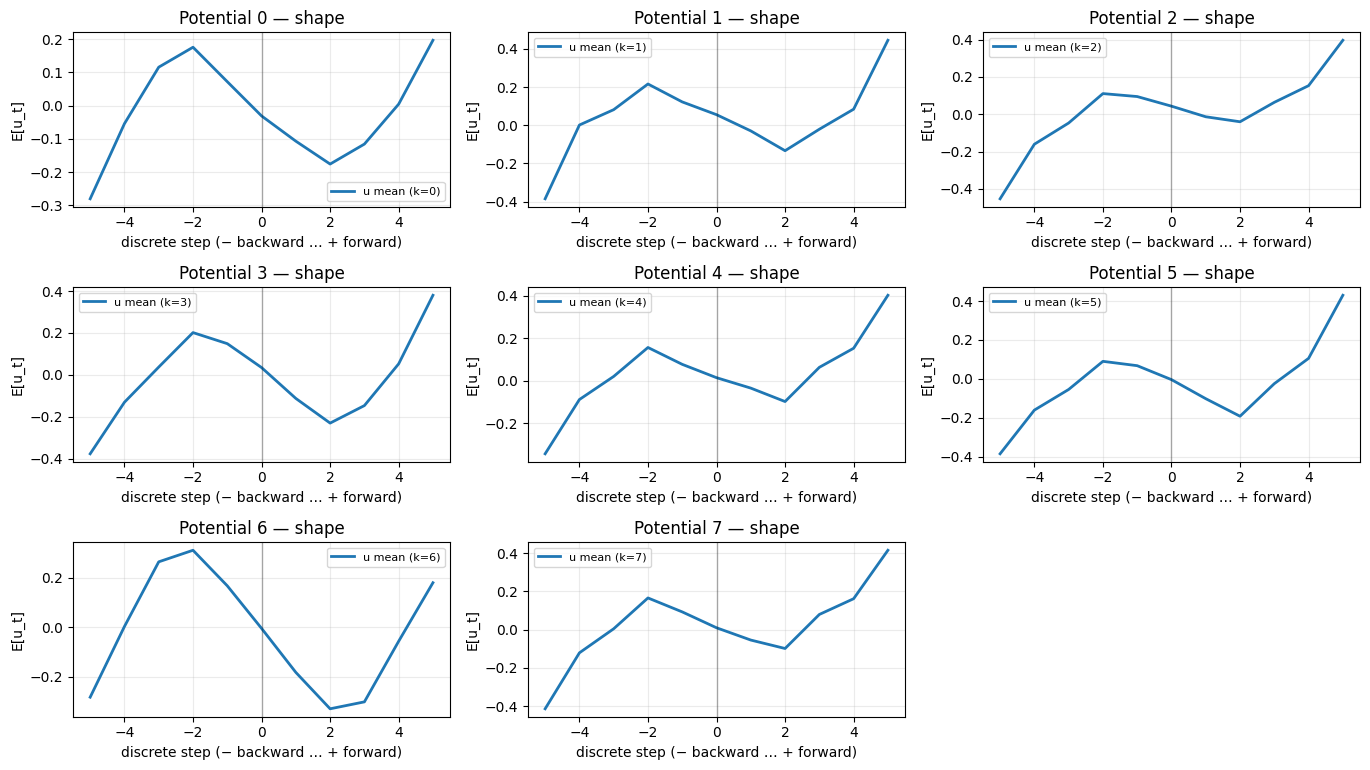

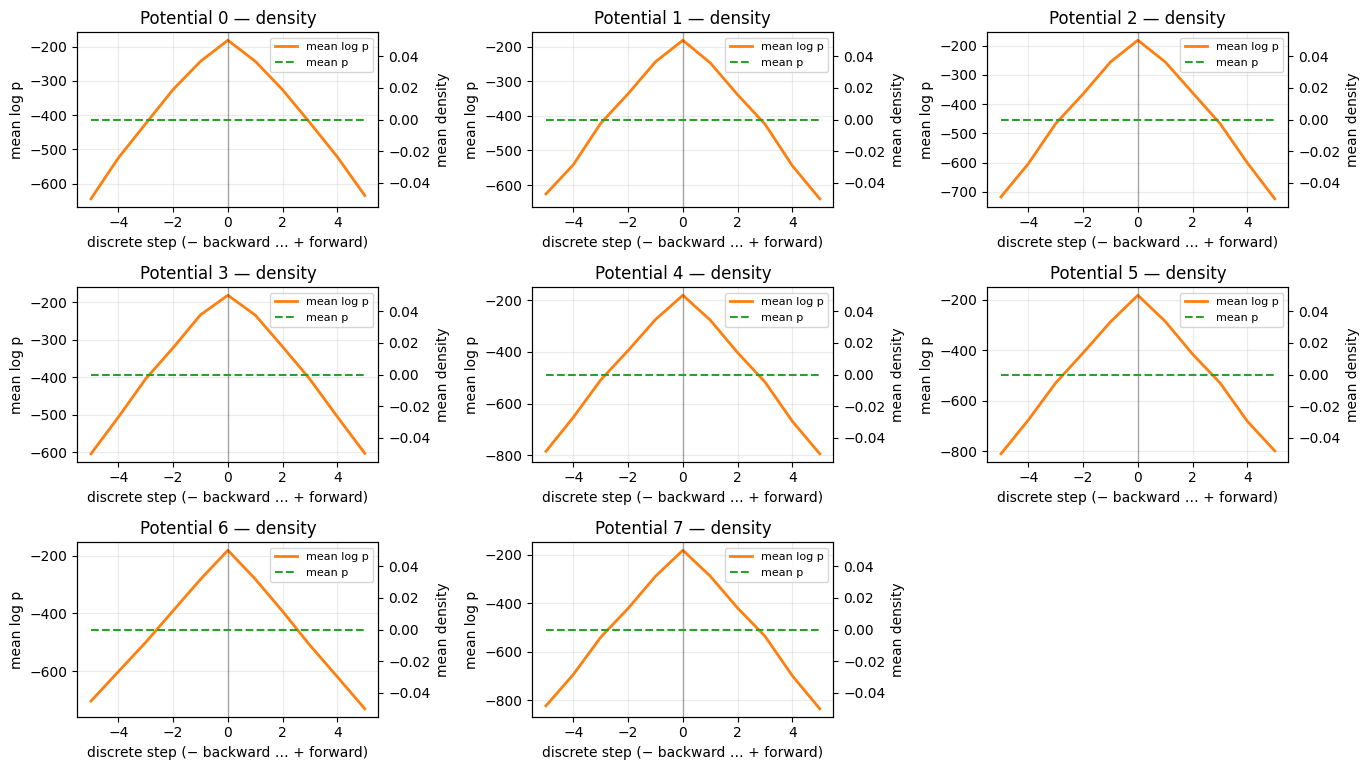

In [10]:
# assume: generator, support_sets already loaded and on device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
generator = generator.to(device).eval()
support_sets = support_sets.to(device).eval()

# Choose a few potentials to inspect (or None for all)
Ks_to_plot = [*range(support_sets.num_support_sets)]

fig1, fig2 = summarize_potential_trajectories(
    support_sets, generator,
    num_samples=2048,        # trade off quality/time
    batch_size=256,
    potentials=Ks_to_plot,
    half_range=None,         # default = num_support_timesteps//2
    use_w=None,              # autodetect via generator.shift_in_w_space
    mu=None, inv_var=None,   # if you already computed W stats, pass them here
    estimate_w_stats_samples=10000,  # faster rough stats for viz
    estimate_w_stats_batch=512,
    truncation_psi=1.0,
    device=device,
    figsize_per_plot=(4.6, 2.6),
    show_density_line=True,
)
# display(fig1)
# display(fig2)